<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/EDA_ML_densidadRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



En esta aplicación implementaremos un modelo de puntuación de riesgo poblacional a la mortalidad debido a los cánceres más comunes y su relación con las cantidades y tecnologías usadas en radioterapia por país.

In [ ]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm




import requests
import unicodedata
import os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression
from urllib.parse import quote




#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatibl

Carga de datos ya depurados

In [ ]:
url = 'https://raw.githubusercontent.com/mehrerm/TFM/refs/heads/main/data/processed/'
df_merged = pd.read_csv(url + "df_merged_WHO.csv")
display(df_merged.head())

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Indicator,Region Name,Year_Units,RT_m,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2015,58.426413,85.680378,7.429043,3747,Belarus,Total density per million population: Radiothe...,Europe,2010,3.02,9487293.0,4414172.0,5073122.0,5967.055951
1,Lung,Female,Incidence,2015,6.135969,12.461069,0.772077,634,Belarus,Total density per million population: Radiothe...,Europe,2010,3.02,9487293.0,4414172.0,5073122.0,5967.055951
2,Lung,Male,Incidence,2015,35.368583,70.075779,4.220175,9215,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105
3,Lung,Male,Mortality,2015,28.561064,59.755594,3.281947,10659,Canada,Total density per million population: Radiothe...,Americas,2010,8.73,35962234.0,17837661.0,18124573.0,43594.194105
4,Lung,Male,Mortality,2018,25.348546,56.824415,2.843197,10521,Canada,Total density per million population: Radiothe...,Americas,2013,8.07,37295005.0,18514929.0,18780076.0,46539.176157


In [ ]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cancer label        1020 non-null   object 
 1   Sex                 1020 non-null   object 
 2   Type                1020 non-null   object 
 3   Year                1020 non-null   int64  
 4   ASR (World)         1020 non-null   float64
 5   Crude rate          1020 non-null   float64
 6   Cumulative risk     1020 non-null   float64
 7   Total               1020 non-null   int64  
 8   Country_harmonized  1020 non-null   object 
 9   Indicator           1020 non-null   object 
 10  Region Name         1020 non-null   object 
 11  Year_Units          1020 non-null   int64  
 12  RT_m                1020 non-null   float64
 13  Population          1020 non-null   float64
 14  Population_male     1020 non-null   float64
 15  Population_female   1020 non-null   float64
 16  GDP_pe

Los datos se encuentran limpios y fucionados en un solo dataframe. Ahora se realiza una exploración previa.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el tiempo, si existen diferencias sistemáticas por sexo y detectar patrones globales.


Primeramente borramos algunas columnas que no nos interesa, como por ejemplo. Indicator, Crude rate	Cumulative y risk	Total.



In [ ]:
df_merged = df_merged.drop(columns=['Crude rate', 'Cumulative risk', "Year_Units", 'Total', 'Indicator'])

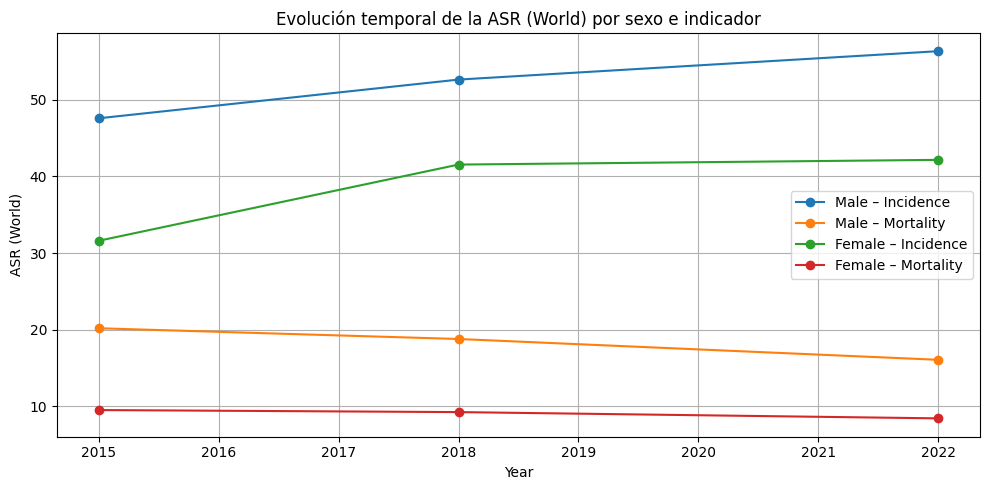

In [ ]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

En a serie temporal no parece evidenciar o estar afecto por el COVID19, los datos del 2018 y 2022 son bastante parecidos, esto también nos podría suponer que no ha evolucionado significativamente la tasa de mortalidad, lo que si queda claro, es que los hombres y mujeres tienen incidencias y mortalidad distintas, con casi los mismo comportamientos pero de magnitud diferente.
En nuestro estudio existen solamente tres años porque son los años que se tiene registro de la cantidad de equipos de radioterapia y su evolución a lo largo de esos tres años registrados, como ya se mencionó en la depuración, se consideró sumarle 5 años a los registros  de los equipos ya que es ese tiempo aproximadamente en el que se puede saber si efectivamente los equipos de radioterapia (A partir de ahora, RT) han surtido efecto en la mortalidad.





Se busca entonces ver como se comporta la mortalidad e incidencia por año.

In [ ]:
idx = (
    df_merged
    .groupby(["Country_harmonized", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

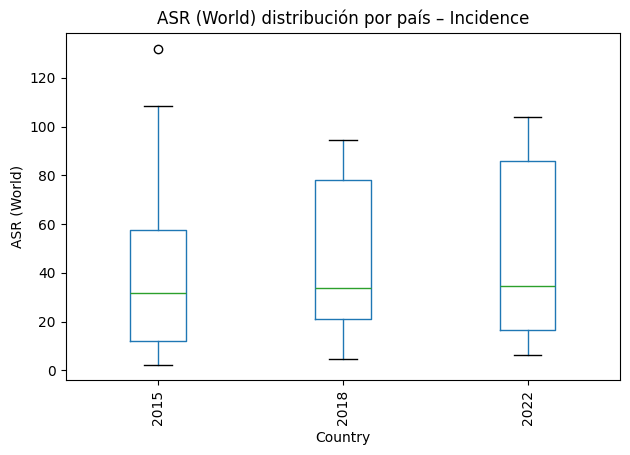

<Figure size 1000x500 with 0 Axes>

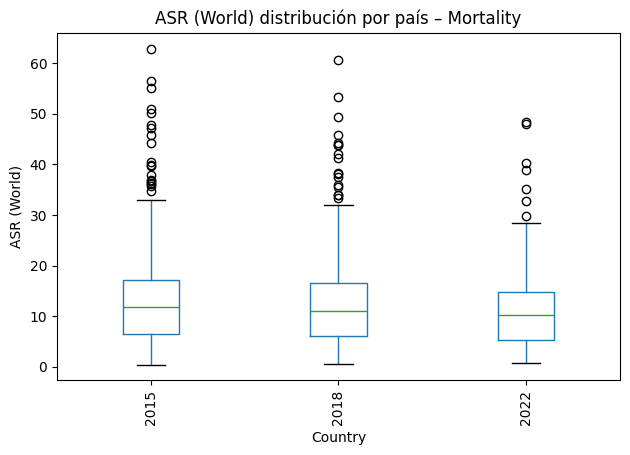

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  215.0  37.990913  29.337718  2.279390  11.803965  31.741894   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2022   20.0  47.815407  35.812019  6.242416  16.589290  34.563362   
Mortality 2015  305.0  13.791938  10.723940  0.388140   6.427067  11.856669   
          2018  285.0  13.072164  10.119124  0.541023   6.054780  11.040429   
          2022  175.0  11.497300   8.685824  0.668701   5.292785  10.249669   

                      75%         max  
Type      Year                         
Incidence 2015  57.439240  132.046692  
          2018  77.994580   94.690075  
          2022  86.004942  103.896318  
Mortality 2015  17.075159   62.917421  
          2018  16.533074   60.588763  
          2022  14.858589   48.374439  


In [ ]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para los años 2015-2018-2022 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. Por el contrario, la mortalidad muestra una distribución con outliers muchos outliers, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios.

Para determinar si se puede utilizar ambas variables,
Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad.


Es importante resaltar desde el principio de que nuestra variable objetivo es la tasa de mortalidad  ASR (World) y ver que relación tiene con los equipos de radioaterapia, incidencia, PIB per capita, sexo, región, etc.



In [ ]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["Country_harmonized", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("Country_harmonized")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 660
Con incidencia y mortalidad: 156
Solo incidencia: 48
Solo mortalidad: 456
Type  both  only_incidence  only_mortality
Year                                      
2015   140              32             104
2018     8               8             220
2022     8               8             132


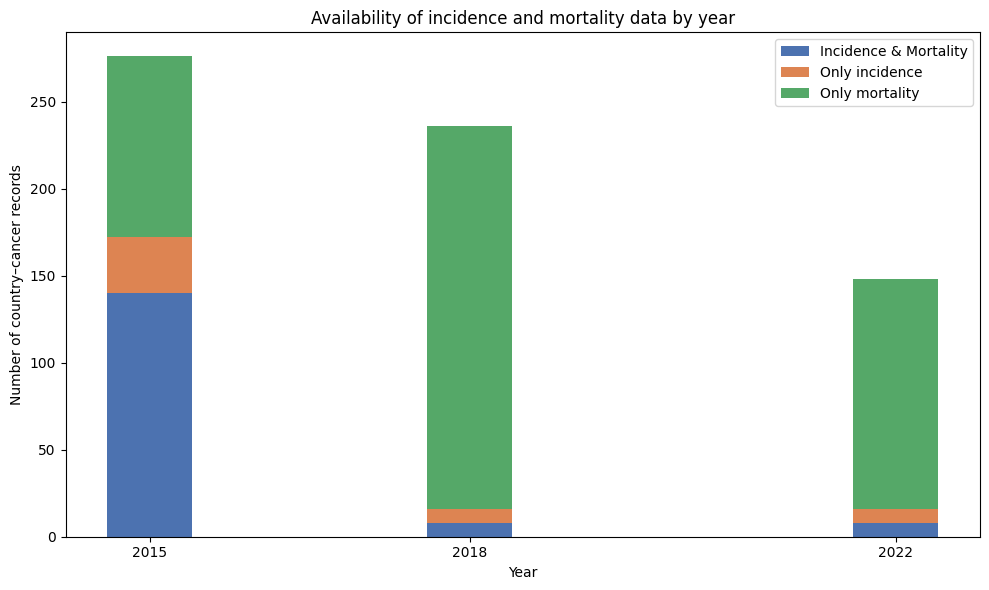

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos de incidencia disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de mortalidad como variable objetivo.

In [ ]:

df_merged_all = df_merged.copy()


# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()



# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


,count
Year,
2015,305
2018,285
2022,175


Con estos datos, ahora si, se procede a evaluar con gráficos y estadísitcas que se tiene por cada tipo de cancer.

In [ ]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

Con la finalidad de entender si existe algún patrón de comportamiento de estos tipos de cancer con variables como PIB y RT, se procede a utilizar graficos de dispersión.

In [ ]:
#Se renombran las columnas
df_model = df_merged_all.rename(columns={
    "Cancer label": "Cancer",
    "Region Name": "Region",
    "Country_harmonized": "Country",
    "ASR (World)" : "ASR",
    "GDP_per_capita" : "GDP",
    "RT_m" : "RT"
})




In [ ]:
df_model.head()

,Cancer,Sex,Type,Year,ASR,Country,Region,RT,Population,Population_male,Population_female,GDP
3,Lung,Male,Mortality,2015,28.561064,Canada,Americas,8.73,35962234.0,17837661.0,18124573.0,43594.194105
4,Lung,Male,Mortality,2018,25.348546,Canada,Americas,8.07,37295005.0,18514929.0,18780076.0,46539.176157
5,Lung,Male,Mortality,2022,20.689747,Canada,Americas,9.30,38821259.0,19282356.0,19538904.0,56256.800726
7,Lung,Female,Mortality,2015,22.576579,Canada,Americas,8.73,35962234.0,17837661.0,18124573.0,43594.194105
8,Lung,Female,Mortality,2018,20.226551,Canada,Americas,8.07,37295005.0,18514929.0,18780076.0,46539.176157


Se grafica las dispersiones.

In [ ]:
df_model['log_GDP'] = np.log(df_model['GDP'])

In [48]:
def plot_all_cancers(df, x, y):
    fig = px.scatter(
        df,
        x=x,
        y=y,
        color="Cancer",
        facet_col="Sex",
        facet_row="Year",
        hover_name="Country",
        title=f"Grafica de dispersion entre {x} y {y} por tipo de cáncer, año y sexo"
    )
    fig.update_layout(height=800, width=1000)
    fig.show()

plot_all_cancers(df_model, "log_GDP", "ASR")

plot_all_cancers(df_model, "RT", "ASR")



Se observa una tendencia general a que, a mayor PIB per cápita (log_GDP), menor es la Tasa de Mortalidad Estandarizada por Edad (ASR) pero con cierto umbral, donde, un menor per capita supone menor mortalidad, pero a medida que crece hasta cierto punto, baja, esto posiblemente se debe al tabaquismo, contaminación u otro factor no lineal. Esto sugiere que el desarrollo económico hasta cierto punto puede ayudar, asi conjuntamente el sistema sanitario, ambos juegan un papel crucial en la reducción de la mortalidad por cáncer. Sin embargo, esta relación no es perfectamente lineal y varía entre cánceres. Por ejemplo, algunos cánceres pueden mostrar una disminución más pronunciada que otros a medida que aumenta el PIB.

ASR vs. Radioterapia (RT): La relación entre la disponibilidad de equipos de radioterapia y la mortalidad es más compleja y específica de cada cáncer.


Cáncer de Cérvix: Visualmente, es probable que se observe que un aumento en la disponibilidad de RT se correlaciona con una disminución en la ASR, especialmente en rangos bajos de RT, lo que podría ser debido a un efecto umbral. Los puntos de datos para este cáncer se concentran en la parte inferior izquierda de los gráficos cuando hay poca RT y se desplazan aún mas hacia abajo y a la derecha a medida que aumenta la RT.
Cáncer de Mama y Próstata: Para estos cánceres, la relación con la RT parece menos consistente o más dispersa. Los puntos de datos pueden estar más agrupados o mostrar una correlación más débil.

Diferencias por Sexo y Año: Los gráficos revelan que las tendencias pueden variar entre hombres y mujeres para el mismo tipo de cáncer, y también a lo largo de los años, usando el cancer de pulmon para este fin.


Con el objetivo de identificar las variables que podrían influir en la tasa de mortalidad, se realiza un análisis mediante una matriz de correlaciones, diferenciando por sexo, dado que los patrones de incidencia y mortalidad presentan comportamientos significativamente distintos entre hombres y mujeres.


In [60]:
df_model_f = df_model[df_model["Sex"] == "Female"].copy()
df_model_f.drop(columns=["Population_male", "Type", "Sex"], inplace=True)


,Cancer,Sex,Type,Year,ASR,Country,Region,RT,Population,Population_female,GDP,log_GDP
7,Lung,Female,Mortality,2015,22.576579,Canada,Americas,8.73,35962234.0,18124573.0,43594.194105,10.682679
8,Lung,Female,Mortality,2018,20.226551,Canada,Americas,8.07,37295005.0,18780076.0,46539.176157,10.748050
9,Lung,Female,Mortality,2022,17.433952,Canada,Americas,9.30,38821259.0,19538904.0,56256.800726,10.937682
14,Lung,Female,Mortality,2015,8.143624,Chile,Americas,0.93,18047625.0,9071160.0,13433.920299,9.505538
15,Lung,Female,Mortality,2018,7.889195,Chile,Americas,0.91,18893191.0,9495561.0,15659.480868,9.658832


In [61]:
df_model_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 459 entries, 7 to 1011
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancer             459 non-null    object 
 1   Sex                459 non-null    object 
 2   Type               459 non-null    object 
 3   Year               459 non-null    int64  
 4   ASR                459 non-null    float64
 5   Country            459 non-null    object 
 6   Region             459 non-null    object 
 7   RT                 459 non-null    float64
 8   Population         459 non-null    float64
 9   Population_female  459 non-null    float64
 10  GDP                459 non-null    float64
 11  log_GDP            459 non-null    float64
dtypes: float64(6), int64(1), object(5)
memory usage: 46.6+ KB


In [63]:
df_model_m = df_model[df_model["Sex"] == "Male"].copy()
df_model_m.drop(columns=["Population_female", "Type", "Sex"], inplace=True)
df_model_m.head()


,Cancer,Year,ASR,Country,Region,RT,Population,Population_male,GDP,log_GDP
3,Lung,2015,28.561064,Canada,Americas,8.73,35962234.0,17837661.0,43594.194105,10.682679
4,Lung,2018,25.348546,Canada,Americas,8.07,37295005.0,18514929.0,46539.176157,10.748050
5,Lung,2022,20.689747,Canada,Americas,9.30,38821259.0,19282356.0,56256.800726,10.937682
11,Lung,2015,14.480369,Chile,Americas,0.93,18047625.0,8976465.0,13433.920299,9.505538
12,Lung,2018,13.518636,Chile,Americas,0.91,18893191.0,9397629.0,15659.480868,9.658832


In [64]:
df_model_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306 entries, 3 to 1019
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cancer           306 non-null    object 
 1   Year             306 non-null    int64  
 2   ASR              306 non-null    float64
 3   Country          306 non-null    object 
 4   Region           306 non-null    object 
 5   RT               306 non-null    float64
 6   Population       306 non-null    float64
 7   Population_male  306 non-null    float64
 8   GDP              306 non-null    float64
 9   log_GDP          306 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 26.3+ KB


Ahora, se buscan las variables que nos interesa

In [70]:
df = df_model_m.copy()


cols_corr_m = [
    "ASR", "RT", "Population_male", "log_GDP"
]

In [72]:


corr_m = df[cols_corr_m].corr()
corr_m

,ASR,RT,Population_male,log_GDP
ASR,1.000000,0.029628,-0.101306,-0.002142
RT,0.029628,1.000000,0.265068,0.750617
Population_male,-0.101306,0.265068,1.000000,0.108722
log_GDP,-0.002142,0.750617,0.108722,1.000000


Lo que se puede ver es que la señal es bastante débil si juntamos las variables, ahora bien, debido a que cada tipo de cancer tiene su protocolo y no son comparables, se estratifica por tipo de cancer.

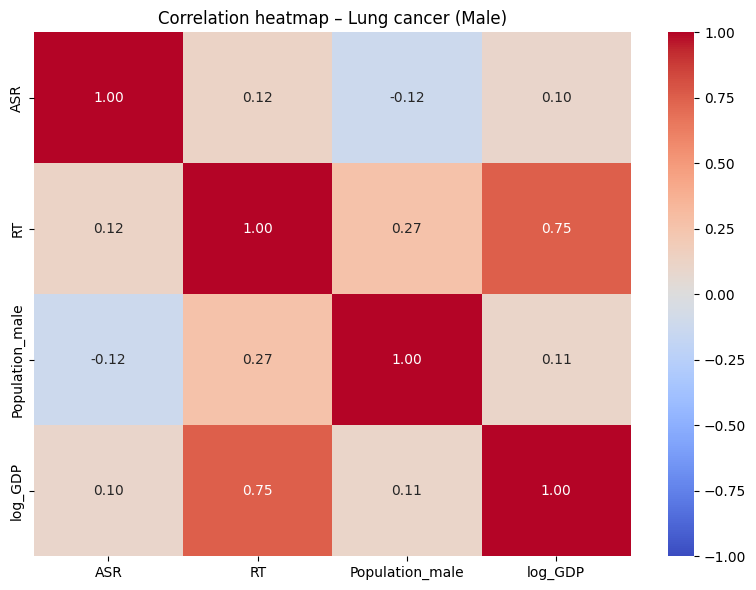

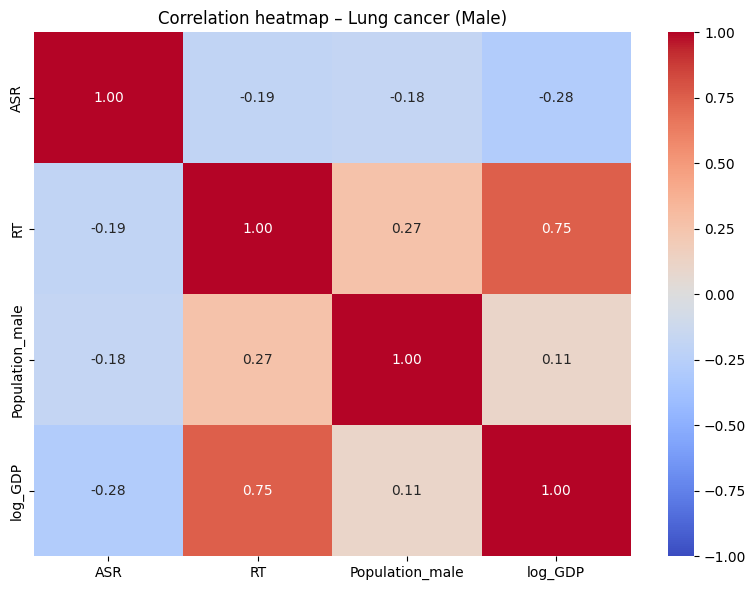

In [73]:
df = df_model_m.copy()

df_lung = df[df["Cancer"] == "Lung"]
df_prostate = df[df["Cancer"] == "Prostate"]

corr_lung = df_lung[cols_corr_m].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_lung,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation heatmap – Lung cancer (Male)")
plt.tight_layout()
plt.show()


corr_prostate = df_prostate[cols_corr_m].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_prostate,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation heatmap – Lung cancer (Male)")
plt.tight_layout()
plt.show()


In [68]:
df = df_model_f.copy()


cols_corr = [
    "ASR", "RT", "Population_female", "log_GDP"
]

corr = df[cols_corr].corr()
corr

,ASR,RT,Population_female,log_GDP
ASR,1.000000,0.077847,-0.002871,0.044492
RT,0.077847,1.000000,0.260900,0.750617
Population_female,-0.002871,0.260900,1.000000,0.106159
log_GDP,0.044492,0.750617,0.106159,1.000000


El mapa de calor revela patrones heterogéneos en la relación entre densidad de radioterapia y mortalidad según el tipo de cáncer. En particular, el cáncer de cérvix muestra una reducción abrupta de la mortalidad al superar niveles medios de dotación de radioterapia, evidenciando un claro efecto umbral. En contraste, otros cánceres como pulmón presentan patrones inversos, probablemente asociados a diferencias en detección y registro más que a un efecto causal directo de la radioterapia. Estos resultados refuerzan la necesidad de enfoques diferenciados en la planificación de infraestructuras de radioterapia, priorizando aquellos cánceres donde el impacto potencial es mayor.

In [ ]:

# Probar múltiples puntos de corte
cutoffs = np.linspace(2, 4, 8, 15)

results = []

for cutoff in cutoffs:
    group_low = df_cervix[df_cervix['RT_m'] < cutoff]['ASR (World)']
    group_high = df_cervix[df_cervix['RT_m'] >= cutoff]['ASR (World)']

    if len(group_low) > 10 and len(group_high) > 10:
        t_stat, p_val = stats.ttest_ind(group_low, group_high)
        diff = abs(group_low.mean() - group_high.mean())

        results.append({
            'Cutoff': cutoff,
            'Diff_ASR': diff,
            'p_value': p_val,
            'n_low': len(group_low),
            'n_high': len(group_high)
        })

df_results = pd.DataFrame(results)
best_cutoff = df_results.loc[df_results['Diff_ASR'].idxmax(), 'Cutoff']
print(f"Mejor punto de corte: {best_cutoff:.2f}")

Mejor punto de corte: 2.57


In [ ]:
!pip install pwlf


In [ ]:
!pip install pwlf
import pwlf  # piecewise linear fit

x = df_cervix["RT_m"].values
y = df_cervix["ASR (World)"].values

my_pwlf = pwlf.PiecewiseLinFit(x, y)
breaks = my_pwlf.fit(2)   # 2 segmentos → 1 breakpoint

breakpoint = breaks[1]
print(f"Breakpoint estimado: {breakpoint:.2f} RT/m")

Breakpoint estimado: 3.08 RT/m


In [ ]:
import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015, mort_2015 = rt_m_mortality_analysis(df_model, 2015, "Cervix")
r_2015, p_2015 = stats.pearsonr(rt_2015, mort_2015)

# 2018
rt_2018, mort_2018 = rt_m_mortality_analysis(df_model, 2018, "Cervix")
r_2018, p_2018 = stats.pearsonr(rt_2018, mort_2018)

# 2022
rt_2022, mort_2022 = rt_m_mortality_analysis(df_model, 2022, "Cervix")
r_2022, p_2022 = stats.pearsonr(rt_2022, mort_2022)

print(f"Correlación 2018: r={r_2018:.3f}, p={p_2018:.10f}")
print(f"Correlación 2015: r={r_2015:.3f}, p={p_2015:.10f}")
print(f"Correlación 2022: r={r_2022:.3f}, p={p_2022:.10f}")


slope_2015, intercept_2015, r_val_2015, p_val_2015, _ = \
    stats.linregress(rt_2015, mort_2015)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015**2:.3f}")
print(f"  p-value: {p_val_2015:.3f}")

slope_2018, intercept_2018, r_val_2018, p_val_2018, _ = \
    stats.linregress(rt_2018, mort_2018)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018**2:.3f}")
print(f"  p-value: {p_val_2018:.3f}")


slope_2022, intercept_2022, r_val_2022, p_val_2022, _ = \
    stats.linregress(rt_2022, mort_2022)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022**2:.3f}")
print(f"  p-value: {p_val_2022:.3f}")




threshold = round(breakpoint)    # RT por millón

low_rt = mort_2015[rt_2015 < threshold]
high_rt = mort_2015[rt_2015 >= threshold]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {threshold}: {np.mean(low_rt):.2f} ASR")
print(f"  RT_m ≥ {threshold}: {np.mean(high_rt):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt) - np.mean(high_rt):.2f} ASR")

t_stat, p_value = stats.ttest_ind(low_rt, high_rt, equal_var=False)
print(f"  t-test p-value: {p_value:.10f}")



Correlación 2018: r=-0.621, p=0.0000002584
Correlación 2015: r=-0.651, p=0.0000000136
Correlación 2022: r=-0.626, p=0.0000585004

Regresión 2015:
  Pendiente: -0.651 (Δ mortalidad por unidad RT_m)
  R²: 0.424
  p-value: 0.000

Regresión 2018:
  Pendiente: -0.685 (Δ mortalidad por unidad RT_m)
  R²: 0.385
  p-value: 0.000

Regresión 2022:
  Pendiente: -0.344 (Δ mortalidad por unidad RT_m)
  R²: 0.391
  p-value: 0.000

2015 - Mortalidad promedio:
  RT_m < 3: 5.92 ASR
  RT_m ≥ 3: 2.11 ASR
  Diferencia: 3.82 ASR
  t-test p-value: 0.0000000346


Ahora usando todas las observaciones

In [ ]:
import statsmodels.api as sm


X = df_cervix[["RT_m", "log_GDP_per_capita", "Year"]]
X = sm.add_constant(X)

y = df_cervix["ASR (World)"]

model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ASR (World)   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     102.4
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           9.06e-29
Time:                        13:17:13   Log-Likelihood:                -306.54
No. Observations:                 153   AIC:                             619.1
Df Residuals:                     150   BIC:                             628.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 22.5845      1.992     11.338      0.000      18.649      26.520
RT_m                  -0.0923      0.069     -1.341      0.182      -0.228       0.044
log_GDP_per_capita    -1.8784      0.223     -8.407      0.000      -2.320      -1.437
==============================================================================
Omnibus:                       43.579   Durbin-Watson:                   1.067
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.893
Skew:                           1.229   Prob(JB):                     1.50e-21
Kurtosis:                       6.001   Cond. No.                         150.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X = df_cervix[["RT_m", "log_GDP_per_capita", "Year"]].values
y = df_cervix["ASR (World)"].values
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

best_model = grid.best_estimator_
print("Mejor alpha:", grid.best_params_)
print("R² CV:", grid.best_score_)
coefs = best_model.named_steps["ridge"].coef_
variables = ["RT_m", "log_GDP_per_capita", "Year"]

for v, c in zip(variables, coefs):
    print(f"{v}: {c:.3f}")


Mejor alpha: {'ridge__alpha': np.float64(0.001)}
R² CV: 0.5489498274673225
RT_m: -0.311
log_GDP_per_capita: -1.859
Year: 0.033


Incluso tras aplicar regularización Ridge para corregir la multicolinealidad, el equipamiento radioterápico per cápita mantiene un efecto independiente y negativo sobre la mortalidad ASR por cáncer de cérvix, aunque claramente inferior al del PIB per cápita.

MAMA

In [ ]:
df_MAMA = df_model[
    (df_model["Cancer_label"] == "Breast") &
    (df_model["RT_m"].notna()) &
    (df_model["ASR (World)"].notna())]

x = df_MAMA["RT_m"].values
y = df_MAMA["ASR (World)"].values

my_pwlfMAMA = pwlf.PiecewiseLinFit(x, y)
breaksMAMA = my_pwlfMAMA.fit(2)   # 2 segmentos → 1 breakpoint

breakpointMAMA = breaksMAMA[1]
print(f"Breakpoint estimado: {breakpointMAMA:.2f} RT/m")

Breakpoint estimado: 2.42 RT/m


In [ ]:
import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015Breast, mort_2015Breast = rt_m_mortality_analysis(df_MAMA, 2015, "Breast")
r_2015Breast, p_2015Breast = stats.pearsonr(rt_2015, mort_2015)

# 2018
rt_2018Breast, mort_2018Breast = rt_m_mortality_analysis(df_MAMA, 2018, "Breast")
r_2018Breast, p_2018Breast = stats.pearsonr(rt_2018, mort_2018)

# 2022
rt_2022Breast, mort_2022Breast = rt_m_mortality_analysis(df_MAMA, 2022, "Breast")
r_2022Breast, p_2022Breast = stats.pearsonr(rt_2022Breast, mort_2022Breast)

print(f"Correlación 2018: r={r_2018Breast:.3f}, p={p_2018Breast:.10f}")
print(f"Correlación 2015: r={r_2015Breast:.3f}, p={p_2015Breast:.10f}")
print(f"Correlación 2022: r={r_2022Breast:.3f}, p={p_2022Breast:.10f}")


slope_2015Breast, intercept_2015Breast, r_val_2015Breast, p_val_2015Breast, _ = \
    stats.linregress(rt_2015Breast, mort_2015Breast)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015Breast**2:.3f}")
print(f"  p-value: {p_val_2015Breast:.3f}")

slope_2018Breast, intercept_2018Breast, r_val_2018Breast, p_val_2018Breast, _ = \
    stats.linregress(rt_2018Breast, mort_2018Breast)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018Breast**2:.3f}")
print(f"  p-value: {p_val_2018Breast:.3f}")


slope_2022Breast, intercept_202Breast2, r_val_2022Breast, p_val_2022Breast, _ = \
    stats.linregress(rt_2022Breast, mort_2022Breast)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022Breast:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022Breast**2:.3f}")
print(f"  p-value: {p_val_2022Breast:.3f}")




thresholdBreast = round(breakpointMAMA)    # RT por millón

low_rt = mort_2015Breast[rt_2015Breast < thresholdBreast]
high_rt = mort_2015Breast[rt_2015Breast >= thresholdBreast]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {thresholdBreast}: {np.mean(low_rt):.2f} ASR")
print(f"  RT_m ≥ {thresholdBreast}: {np.mean(high_rt):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt) - np.mean(high_rt):.2f} ASR")

t_stat, p_value = stats.ttest_ind(low_rt, high_rt, equal_var=False)
print(f"  t-test p-value: {p_value:.10f}")


Correlación 2018: r=-0.621, p=0.0000002584
Correlación 2015: r=-0.651, p=0.0000000136
Correlación 2022: r=0.114, p=0.5153218590

Regresión 2015:
  Pendiente: 0.046 (Δ mortalidad por unidad RT_m)
  R²: 0.001
  p-value: 0.769

Regresión 2018:
  Pendiente: 0.105 (Δ mortalidad por unidad RT_m)
  R²: 0.007
  p-value: 0.532

Regresión 2022:
  Pendiente: 0.100 (Δ mortalidad por unidad RT_m)
  R²: 0.013
  p-value: 0.515

2015 - Mortalidad promedio:
  RT_m < 2: 13.07 ASR
  RT_m ≥ 2: 14.28 ASR
  Diferencia: -1.21 ASR
  t-test p-value: 0.2435247179


“La asociación observada en análisis bivariantes tempranos no se mantiene en años posteriores ni en modelos lineales, sugiriendo que la mortalidad por cáncer de mama está dominada por otros factores distintos del equipamiento radioterápico per cápita.”

prostata

In [ ]:
df_p = df_model[
    (df_model["Cancer_label"] == "Prostate") &
    (df_model["RT_m"].notna()) &
    (df_model["ASR (World)"].notna())].copy()

x = df_p["RT_m"].values
y = df_p["ASR (World)"].values

my_pwlfp = pwlf.PiecewiseLinFit(x, y)
breaksp = my_pwlfp.fit(2)   # 2 segmentos → 1 breakpoint

breakpointp = breaksp[1]
print(f"Breakpoint estimado: {breakpointp:.2f} RT/m")

Breakpoint estimado: 0.01 RT/m


In [ ]:



import numpy as np
from scipy import stats

def rt_m_mortality_analysis(df, year, cancer):
    df_y = df[
        (df["Year"] == year) &
        (df["RT_m"].notna()) &
        (df["Cancer_label"] == cancer) &
        (df["ASR (World)"].notna())
    ]

    x = df_y["RT_m"].values
    y = df_y["ASR (World)"].values

    return x, y
#2015
rt_2015p, mort_2015p = rt_m_mortality_analysis(df_p, 2015, "Prostate")
r_2015p, p_2015p = stats.pearsonr(rt_2015p, mort_2015p)

# 2018
rt_2018p, mort_2018p = rt_m_mortality_analysis(df_p, 2018, "Prostate")
r_2018p, p_2018p = stats.pearsonr(rt_2018p, mort_2018p)

# 2022
rt_2022p, mort_2022p = rt_m_mortality_analysis(df_p, 2022, "Prostate")
r_2022p, p_2022p = stats.pearsonr(rt_2022p, mort_2022p)

print(f"Correlación 2018: r={r_2018p:.3f}, p={p_2018p:.10f}")
print(f"Correlación 2015: r={r_2015p:.3f}, p={p_2015p:.10f}")
print(f"Correlación 2022: r={r_2022p:.3f}, p={p_2022p:.10f}")


slope_2015p, intercept_2015p, r_val_2015p, p_val_2015p, _ = \
    stats.linregress(rt_2015p, mort_2015p)

print("\nRegresión 2015:")
print(f"  Pendiente: {slope_2015p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2015p**2:.3f}")
print(f"  p-value: {p_val_2015p:.3f}")

slope_2018p, intercept_2018p, r_val_2018p, p_val_2018p, _ = \
    stats.linregress(rt_2018p, mort_2018p)

print("\nRegresión 2018:")
print(f"  Pendiente: {slope_2018p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2018p**2:.3f}")
print(f"  p-value: {p_val_2018p:.3f}")


slope_2022p, intercept_2022p, r_val_2022p, p_val_2022p, _ = \
    stats.linregress(rt_2022p, mort_2022p)

print("\nRegresión 2022:")
print(f"  Pendiente: {slope_2022p:.3f} (Δ mortalidad por unidad RT_m)")
print(f"  R²: {r_val_2022p**2:.3f}")
print(f"  p-value: {p_val_2022p:.3f}")




thresholdProstate = round(breakpointp)    # RT por millón

low_rt_p = mort_2015p[rt_2015p < thresholdProstate]
high_rt_p = mort_2015p[rt_2015p >= thresholdProstate]

print("\n2015 - Mortalidad promedio:")
print(f"  RT_m < {thresholdProstate}: {np.mean(low_rt_p):.2f} ASR")
print(f"  RT_m ≥ {thresholdProstate}: {np.mean(high_rt_p):.2f} ASR")
print(f"  Diferencia: {np.mean(low_rt_p) - np.mean(high_rt_p):.2f} ASR")

t_stat_p, p_value_p = stats.ttest_ind(low_rt_p, high_rt_p, equal_var=False)
print(f"  t-test p-value: {p_value_p:.10f}")

Correlación 2018: r=-0.161, p=0.2324732050
Correlación 2015: r=-0.230, p=0.0742567234
Correlación 2022: r=-0.010, p=0.9527031011

Regresión 2015:
  Pendiente: -0.409 (Δ mortalidad por unidad RT_m)
  R²: 0.053
  p-value: 0.074

Regresión 2018:
  Pendiente: -0.304 (Δ mortalidad por unidad RT_m)
  R²: 0.026
  p-value: 0.232

Regresión 2022:
  Pendiente: -0.009 (Δ mortalidad por unidad RT_m)
  R²: 0.000
  p-value: 0.953

2015 - Mortalidad promedio:
  RT_m < 0: nan ASR
  RT_m ≥ 0: 12.74 ASR
  Diferencia: nan ASR
  t-test p-value: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


En el caso del cáncer de próstata, no se identificaron asociaciones consistentes ni estables entre el equipamiento radioterápico per cápita y la mortalidad ASR, por lo que no se procedió a análisis multivariante adicional.

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ ML usando los datos de Cervix  +++++++++++++++++++++++++++++++++++

In [ ]:
print(df_cervix.isna().sum())

ASR (World)           0
RT_m                  0
log_GDP_per_capita    0
Year                  0
dtype: int64


In [ ]:
# Separar features (X) y target (y)

feature_cols = ["RT_m", "log_GDP_per_capita", "Year"]

X = df_cervix[feature_cols].copy()
y = df_cervix["ASR (World)"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX head:")
print(X.head())
print("\ny head:")
print(y.head())


X shape: (153, 3)
y shape: (153,)

X head:
   RT_m  log_GDP_per_capita  Year
0  8.73           10.682702  2015
1  8.07           10.748071  2018
2  9.30           10.937700  2022
3  0.93            9.505613  2015
4  0.91            9.658896  2018

y head:
0    1.316405
1    1.166648
2    1.233960
3    4.607123
4    4.194128
Name: ASR (World), dtype: float64


In [ ]:


X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:            ASR (World)   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     67.85
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.02e-27
Time:                        14:53:57   Log-Likelihood:                -306.52
No. Observations:                 153   AIC:                             621.0
Df Residuals:                     149   BIC:                             633.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.4532    116

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(
    lr, X, y,
    cv=cv,
    scoring="r2"
)

rmse_scores = -cross_val_score(
    lr, X, y,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print(f"OLS CV R²:  {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"OLS CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")


OLS CV R²:  0.525 ± 0.096
OLS CV RMSE: 1.776 ± 0.579


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X, y)

best_ridge = grid.best_estimator_

print("Mejor alpha:", grid.best_params_)
print("Ridge CV R²:", grid.best_score_)


Mejor alpha: {'ridge__alpha': np.float64(0.001)}
Ridge CV R²: 0.5489498274673223


La aplicación de técnicas de regularización (Ridge) no produjo mejoras sustanciales respecto al modelo lineal clásico, lo que indica que la estructura del problema está dominada por relaciones lineales estables y por variables macroeconómicas, y que modelos más complejos difícilmente aportarán capacidad predictiva adicional.

Ahora, se hará un arbol de decisión poco profundo

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

tree = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=15,
    random_state=42
)

r2_tree = cross_val_score(
    tree, X, y,
    cv=5,
    scoring="r2"
)

rmse_tree = -cross_val_score(
    tree, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print(f"Tree CV R²:  {r2_tree.mean():.3f} ± {r2_tree.std():.3f}")
print(f"Tree CV RMSE: {rmse_tree.mean():.3f} ± {rmse_tree.std():.3f}")


Tree CV R²:  0.300 ± 0.311
Tree CV RMSE: 2.040 ± 0.281


Los modelos no lineales no aportan mejoras sustanciales frente a enfoques lineales regulares, lo que sugiere que la relación entre mortalidad por cáncer de cérvix y la disponibilidad de radioterapia está dominada por factores estructurales lineales, principalmente el nivel de renta, y que la complejidad adicional no se traduce en mayor capacidad predictiva.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

def nested_cv_regression(estimator, param_grid, X, y, *,
                         outer_splits=5, inner_splits=5, random_state=42):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

    outer_r2 = []
    outer_rmse = []
    best_params_list = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=inner_cv,
            scoring="r2"
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        outer_r2.append(r2_score(y_test, y_pred))
        outer_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        best_params_list.append(search.best_params_)

    return {
        "r2_mean": float(np.mean(outer_r2)),
        "r2_std": float(np.std(outer_r2, ddof=1)),
        "rmse_mean": float(np.mean(outer_rmse)),
        "rmse_std": float(np.std(outer_rmse, ddof=1)),
        "best_params_per_fold": best_params_list
    }

# ---------- 1) Ridge (requiere estandarizar) ----------
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

ridge_nested = nested_cv_regression(ridge_pipe, ridge_grid, X, y)
print("Nested CV — Ridge")
print(f"  R²:   {ridge_nested['r2_mean']:.3f} ± {ridge_nested['r2_std']:.3f}")
print(f"  RMSE: {ridge_nested['rmse_mean']:.3f} ± {ridge_nested['rmse_std']:.3f}")
print("  Best params (outer folds):", ridge_nested["best_params_per_fold"])


# ---------- 2) Árbol (no necesita escalado) ----------
tree = DecisionTreeRegressor(random_state=42)

tree_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10, 15, 20, 25]
}

tree_nested = nested_cv_regression(tree, tree_grid, X, y)
print("\nNested CV — Decision Tree")
print(f"  R²:   {tree_nested['r2_mean']:.3f} ± {tree_nested['r2_std']:.3f}")
print(f"  RMSE: {tree_nested['rmse_mean']:.3f} ± {tree_nested['rmse_std']:.3f}")
print("  Best params (outer folds):", tree_nested["best_params_per_fold"])


Nested CV — Ridge
  R²:   0.521 ± 0.103
  RMSE: 1.788 ± 0.666
  Best params (outer folds): [{'ridge__alpha': np.float64(10.985411419875572)}, {'ridge__alpha': np.float64(2.6826957952797246)}, {'ridge__alpha': np.float64(8.286427728546842)}, {'ridge__alpha': np.float64(10.985411419875572)}, {'ridge__alpha': np.float64(14.563484775012444)}]

Nested CV — Decision Tree
  R²:   0.533 ± 0.211
  RMSE: 1.719 ± 0.671
  Best params (outer folds): [{'max_depth': 2, 'min_samples_leaf': 10}, {'max_depth': 2, 'min_samples_leaf': 5}, {'max_depth': 2, 'min_samples_leaf': 5}, {'max_depth': 2, 'min_samples_leaf': 10}, {'max_depth': 3, 'min_samples_leaf': 15}]


Los modelos no lineales no aportan mejoras robustas frente a enfoques lineales regularizados. Aunque un árbol de decisión poco profundo puede alcanzar un rendimiento medio similar, su elevada variabilidad entre particiones indica una menor estabilidad y capacidad de generalización

Los resultados tras evaluar distintos modelos se tienen que:
| Modelo | Tipo            | R² (Nested CV) | RMSE (Nested CV) | Estabilidad |
| ------ | --------------- | -------------- | ---------------- | ----------- |
| OLS    | Lineal clásico  | ~0.52          | ~1.78            | Alta        |
| Ridge  | ML regularizado | 0.52 ± 0.10    | 1.79 ± 0.67      | Alta        |
| Árbol  | ML no lineal    | 0.53 ± 0.21    | 1.72 ± 0.67      | Baja        |


La validación cruzada anidada confirma que los enfoques lineales, tanto clásicos como regularizados, capturan de forma estable la relación entre mortalidad por cáncer de cérvix y las variables estructurales consideradas. Los modelos no lineales no aportan mejoras robustas en capacidad predictiva y presentan una mayor variabilidad entre particiones, lo que sugiere que la complejidad adicional no se traduce en una mejor generalización.

La mortalidad por cáncer de cérvix es sistemáticamente mayor en países con baja disponibilidad de radioterapia per cápita, incluso tras controlar por nivel económico, lo que sugiere que la radioterapia forma parte de un cuello de botella estructural del sistema oncológico.


In [ ]:
coefs = best_ridge.named_steps["ridge"].coef_
for name, coef in zip(X.columns, coefs):
    print(f"{name}: {coef:.3f}")


RT_m: -0.311
log_GDP_per_capita: -1.859
Year: 0.033


In [ ]:
from optbinning import OptimalBinning

optb = OptimalBinning(
    name="RT_m",
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_model["RT_m"],
    df_model["High_Mortality"]
)

df_model["RT_m_woe"] = optb.transform(
    df_model["RT_m"],
    metric="woe"
)


In [ ]:
df_model.info()

In [ ]:
from optbinning import OptimalBinning
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd

# 1. Preparar datos
df_model = df_model.rename(columns={
    "Cancer label": "Cancer_label",
    "ASR (World)": "ASR_World"
})

# 2. Split train/test (opcional pero recomendado)
train, test = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['High_Mortality']
)

# 3. Binning WOE (fit solo en train)
optb = OptimalBinning(
    name="RT_m",
    dtype="numerical",
    solver="cp",
    min_bin_size=0.05,  # mínimo 5% obs por bin
    monotonic_trend="auto_asc_desc"  # forzar monotonía si tiene sentido
)

optb.fit(train["RT_m"], train["High_Mortality"])
print("Binning table:")
print(optb.binning_table.build())

# Transformar train y test
train["RT_m_woe"] = optb.transform(train["RT_m"], metric="woe")
test["RT_m_woe"] = optb.transform(test["RT_m"], metric="woe")

# 4. Modelo logit con interacciones
formula = """
    High_Mortality ~ RT_m_woe
    + log_GDP_per_capita
    + C(Sex)
    + C(Cancer_label)
    + C(Period)
    + RT_m_woe:C(Period)
    + RT_m_woe:C(Cancer_label)
"""

model = smf.logit(formula, data=train).fit(cov_type='HC3')  # robust SE
print(model.summary())

# 5. Evaluación en test
test_pred_prob = model.predict(test)
test_pred = (test_pred_prob > 0.5).astype(int)

print("\n=== Test Set Performance ===")
print("AUC:", roc_auc_score(test["High_Mortality"], test_pred_prob))
print(classification_report(test["High_Mortality"], test_pred))

# 6. Efectos marginales (opcional, para interpretación)
import matplotlib.pyplot as plt
# Predecir prob por nivel de RT_m_woe (manteniendo otras vars constantes)
# ... código de visualización si necesitas

In [ ]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

# ============================================================================
# PASO 1: Binning SEPARADO por tipo de cáncer
# ============================================================================

print("="*80)
print("PASO 1: OPTIMAL BINNING POR TIPO DE CÁNCER")
print("="*80)

# Diccionario para guardar los binning objects
woe_binning = {}
binning_tables = {}

for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    print(f"\n{'='*60}")
    print(f"Binning para {cancer}")
    print(f"{'='*60}")

    # Filtrar datos del cáncer específico
    cancer_mask = df_model['Cancer_label'] == cancer
    cancer_data = df_model[cancer_mask].copy()

    print(f"N observaciones: {len(cancer_data)}")
    print(f"Event rate: {cancer_data['High_Mortality'].mean():.2%}")
    print(f"RT_m range: [{cancer_data['RT_m'].min():.2f}, {cancer_data['RT_m'].max():.2f}]")

    # Optimal Binning específico para este cáncer
    optb = OptimalBinning(
        name=f"RT_m_{cancer}",
        dtype="numerical",
        solver="cp",
        min_bin_size=0.05,  # Mínimo 5% de observaciones por bin
        max_n_bins=5,       # Máximo 5 bins (evitar overfitting)
        monotonic_trend="auto_asc_desc"  # Permitir tendencia ascendente o descendente
    )

    # Fit
    optb.fit(cancer_data["RT_m"], cancer_data["High_Mortality"])

    # Guardar
    woe_binning[cancer] = optb
    binning_tables[cancer] = optb.binning_table.build()

    # Mostrar tabla
    print(f"\n{binning_tables[cancer]}")

    # Transformar a WoE para este cáncer
    df_model.loc[cancer_mask, 'RT_m_woe_specific'] = optb.transform(
        cancer_data["RT_m"],
        metric="woe"
    )

# ============================================================================
# PASO 2: Verificar transformación
# ============================================================================

print("\n" + "="*80)
print("PASO 2: VERIFICACIÓN DE WoE ESPECÍFICO")
print("="*80)

# Comparar WoE global vs específico
comparison = df_model.groupby('Cancer_label').agg({
    'RT_m': ['min', 'median', 'max'],
    'RT_m_woe': ['min', 'median', 'max'],
    'RT_m_woe_specific': ['min', 'median', 'max']
}).round(3)

print("\n", comparison)

# Ejemplo de transformación para algunos casos
print("\n=== Ejemplos de transformación (primeros 5 casos por cáncer) ===")
for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    sample = df_model[df_model['Cancer_label'] == cancer].head(5)[[
        'Country_harmonized', 'Period', 'Cancer_label', 'RT_m',
        'RT_m_woe', 'RT_m_woe_specific', 'High_Mortality'
    ]]
    print(f"\n{cancer}:")
    print(sample.to_string(index=False))

# ============================================================================
# PASO 3: Train/Test Split
# ============================================================================

print("\n" + "="*80)
print("PASO 3: TRAIN/TEST SPLIT")
print("="*80)

train, test = train_test_split(
    df_model,
    test_size=0.25,
    random_state=42,
    stratify=df_model[['High_Mortality', 'Cancer_label']]
)

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"\nTrain event rate: {train['High_Mortality'].mean():.2%}")
print(f"Test event rate: {test['High_Mortality'].mean():.2%}")

# ============================================================================
# PASO 4: Modelo con WoE GLOBAL (baseline)
# ============================================================================

print("\n" + "="*80)
print("PASO 4: MODELO BASELINE (WoE GLOBAL)")
print("="*80)

model_global = smf.logit(
    formula="""
        High_Mortality ~ RT_m_woe
        + log_GDP_per_capita
        + C(Sex)
        + C(Cancer_label)
        + C(Period)
        + RT_m_woe:C(Period)
        + RT_m_woe:C(Cancer_label)
    """,
    data=train
).fit(cov_type='HC3', disp=0)

print(model_global.summary())

# Evaluación en test
test['pred_global'] = model_global.predict(test)
auc_global = roc_auc_score(test['High_Mortality'], test['pred_global'])
print(f"\n{'='*60}")
print(f"AUC Test (WoE Global): {auc_global:.4f}")
print(f"{'='*60}")

# ============================================================================
# PASO 5: Modelo con WoE ESPECÍFICO (mejorado)
# ============================================================================

print("\n" + "="*80)
print("PASO 5: MODELO MEJORADO (WoE ESPECÍFICO)")
print("="*80)

model_specific = smf.logit(
    formula="""
        High_Mortality ~ RT_m_woe_specific
        + log_GDP_per_capita
        + C(Sex)
        + C(Cancer_label)
        + C(Period)
        + RT_m_woe_specific:C(Period)
        + RT_m_woe_specific:C(Cancer_label)
    """,
    data=train
).fit(cov_type='HC3', disp=0)

print(model_specific.summary())

# Evaluación en test
test['pred_specific'] = model_specific.predict(test)
auc_specific = roc_auc_score(test['High_Mortality'], test['pred_specific'])
print(f"\n{'='*60}")
print(f"AUC Test (WoE Específico): {auc_specific:.4f}")
print(f"{'='*60}")

# ============================================================================
# PASO 6: Comparación de modelos
# ============================================================================

print("\n" + "="*80)
print("PASO 6: COMPARACIÓN DE MODELOS")
print("="*80)

comparison_metrics = pd.DataFrame({
    'Modelo': ['WoE Global', 'WoE Específico'],
    'AUC Test': [auc_global, auc_specific],
    'Pseudo R²': [model_global.prsquared, model_specific.prsquared],
    'Log-Likelihood': [model_global.llf, model_specific.llf],
    'AIC': [model_global.aic, model_specific.aic],
    'BIC': [model_global.bic, model_specific.bic]
})

print(comparison_metrics.to_string(index=False))

# Test estadístico (Likelihood Ratio Test)
lr_stat = -2 * (model_global.llf - model_specific.llf)
from scipy.stats import chi2
df_diff = model_global.df_model - model_specific.df_model
p_value = 1 - chi2.cdf(lr_stat, abs(df_diff))

print(f"\n{'='*60}")
print(f"Likelihood Ratio Test")
print(f"{'='*60}")
print(f"LR statistic: {lr_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Modelo WoE Específico es significativamente mejor")
else:
    print("⚠️ No hay diferencia significativa entre modelos")

# ============================================================================
# PASO 7: Análisis de coeficientes por cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 7: COEFICIENTES POR TIPO DE CÁNCER")
print("="*80)

# Extraer coeficientes
coef_specific = model_specific.params
conf_int = model_specific.conf_int()

# Efecto baseline (Breast es referencia)
print("\n=== BREAST (baseline) ===")
print(f"RT_m_woe_specific: {coef_specific['RT_m_woe_specific']:.4f}")
print(f"95% CI: [{conf_int.loc['RT_m_woe_specific', 0]:.4f}, {conf_int.loc['RT_m_woe_specific', 1]:.4f}]")
print(f"p-value: {model_specific.pvalues['RT_m_woe_specific']:.4f}")

# Efectos por cáncer
for cancer in ['Cervix', 'Lung', 'Prostate']:
    interaction_term = f'RT_m_woe_specific:C(Cancer_label)[T.{cancer}]'

    if interaction_term in coef_specific.index:
        total_effect = coef_specific['RT_m_woe_specific'] + coef_specific[interaction_term]

        print(f"\n=== {cancer.upper()} ===")
        print(f"Interacción: {coef_specific[interaction_term]:.4f}")
        print(f"Efecto total: {total_effect:.4f}")
        print(f"95% CI interacción: [{conf_int.loc[interaction_term, 0]:.4f}, {conf_int.loc[interaction_term, 1]:.4f}]")
        print(f"p-value: {model_specific.pvalues[interaction_term]:.4f}")

        # Interpretación
        if total_effect > 0:
            print(f"📊 Interpretación: WoE más alto (baja RT) → MAYOR probabilidad alta mortalidad")
            print(f"   → Baja RT se asocia con ALTA mortalidad ✅")
        else:
            print(f"📊 Interpretación: WoE más alto (baja RT) → MENOR probabilidad alta mortalidad")
            print(f"   → Baja RT se asocia con BAJA mortalidad ⚠️ (contraintuitivo)")

# ============================================================================
# PASO 8: Visualización de binning por cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 8: VISUALIZACIÓN DE BINNING")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cancer in enumerate(['Breast', 'Cervix', 'Lung', 'Prostate']):
    ax = axes[idx]

    # Datos del cáncer
    cancer_data = df_model[df_model['Cancer_label'] == cancer].copy()

    # Scatter plot
    colors = ['#e74c3c' if x == 1 else '#3498db' for x in cancer_data['High_Mortality']]
    ax.scatter(cancer_data['RT_m'], cancer_data['ASR_World'],
               c=colors, alpha=0.5, s=40)

    # Bins (líneas verticales)
    binning_obj = woe_binning[cancer]
    splits = binning_obj.splits

    for split in splits:
        ax.axvline(x=split, color='orange', linestyle='--', linewidth=2, alpha=0.7)

    # Etiquetas
    ax.set_xlabel('RT (equipos por millón)', fontsize=11)
    ax.set_ylabel('Mortality ASR (World)', fontsize=11)
    ax.set_title(f'{cancer}: Bins optimizados\n(líneas naranjas = puntos de corte)',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    # Leyenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='High Mortality'),
        Patch(facecolor='#3498db', label='Low Mortality'),
        Patch(facecolor='orange', label='Bin splits')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('binning_por_cancer.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: binning_por_cancer.png")
plt.show()

# ============================================================================
# PASO 9: Performance por tipo de cáncer
# ============================================================================

print("\n" + "="*80)
print("PASO 9: PERFORMANCE POR TIPO DE CÁNCER")
print("="*80)

performance_by_cancer = []

for cancer in ['Breast', 'Cervix', 'Lung', 'Prostate']:
    test_cancer = test[test['Cancer_label'] == cancer].copy()

    if len(test_cancer) > 0:
        auc_global_cancer = roc_auc_score(test_cancer['High_Mortality'], test_cancer['pred_global'])
        auc_specific_cancer = roc_auc_score(test_cancer['High_Mortality'], test_cancer['pred_specific'])

        performance_by_cancer.append({
            'Cancer': cancer,
            'N Test': len(test_cancer),
            'Event Rate': f"{test_cancer['High_Mortality'].mean():.1%}",
            'AUC Global': auc_global_cancer,
            'AUC Específico': auc_specific_cancer,
            'Mejora': auc_specific_cancer - auc_global_cancer
        })

perf_df = pd.DataFrame(performance_by_cancer)
print(perf_df.to_string(index=False))

# ============================================================================
# PASO 10: Exportar resultados
# ============================================================================

print("\n" + "="*80)
print("PASO 10: EXPORTAR RESULTADOS")
print("="*80)

# Guardar binning tables
for cancer, table in binning_tables.items():
    filename = f'binning_table_{cancer}.csv'
    table.to_csv(filename, index=False)
    print(f"✅ Guardado: {filename}")

# Guardar comparación de modelos
comparison_metrics.to_csv('model_comparison.csv', index=False)

Una vez modelada la no linealidad mediante WOE, la densidad de equipos de radioterapia muestra una asociación negativa y estadísticamente significativa con la mortalidad.

En cáncer de cérvix, la disponibilidad de radioterapia muestra un efecto diferencial y reforzado, coherente con su papel central en el tratamiento.


En cáncer de pulmón no se observa un efecto significativo de la densidad de radioterapia, lo que sugiere la influencia de factores clínicos y de detección temprana.


En próstata, la radioterapia muestra un efecto protector significativo, aunque más heterogéneo, probablemente debido a la coexistencia de múltiples estrategias terapéuticas. Es bien sabido que los urologos tienden a mandar a cirugías a este tipo de pacientes, donde lamentablemente no tienen tanto exito en efectos secundarios menores.






Los resultados confirman que la relación entre la disponibilidad de radioterapia y la mortalidad por cáncer es inherentemente no lineal y altamente dependiente del tipo de cáncer. Mientras que el análisis agregado oculta estos efectos, el uso de WOE permite identificar un impacto protector significativo de la radioterapia, particularmente marcado en cáncer de cérvix y, en menor medida, en próstata. No se observan diferencias sustanciales entre los periodos 2015 y 2018, lo que sugiere estabilidad temporal del efecto.

El PIB no introduce un umbral de riesgo, sino un gradiente socioeconómico continuo; por eso no requiere WOE.


In [ ]:
import numpy as np
import pandas as pd

# Extraer coeficientes e intervalos
params = model.params
conf = model.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# Calcular Odds Ratios
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_lower": np.exp(conf["CI_lower"]),
    "CI_upper": np.exp(conf["CI_upper"]),
    "p_value": model.pvalues
})

or_table


En esta tabla podemos ver claramente que los hombres tienen 26 veces más probabilidad de alta mortalidad que las mujeres.

Con respecto a las comparaciones entre tipos de cáncer, todos son ligeramente menor probabilidad de alta mortalidad que el cancer de referencia, independientemente del RT.

Con respecto a ambos períodos a estudiar, no es significativo, evidenciando estabilidad temporal.

El modelo sugiere que no es el aumento marginal de equipos lo que reduce la mortalidad, sino alcanzar niveles suficientes de infraestructura de radioterapia. Una vez que un país pasa de una dotación insuficiente a una adecuada, el riesgo de alta mortalidad disminuye de forma muy marcada.
El salto estructural donde se pasa de una baja a alta mortalidad es en OR=0.076, esto quiere decir que al pasar un bin WOE, las probabilidades de alta mortalidad caen un 92%.

Un incremento de una unidad en el WOE de la densidad de radioterapia representa el paso a un grupo de países con mayor disponibilidad relativa de equipos. Este cambio se asocia con una reducción aproximada del 92 % en la probabilidad de alta mortalidad, lo que evidencia un efecto protector no lineal de la radioterapia.

In [ ]:
df_model["RT_m_woe"].unique()


In [ ]:
woe_bins = (
    df_model
    .groupby("RT_m_woe")["RT_m"]
    .agg(
        RT_min="min",
        RT_max="max",
        n="count"
    )
    .reset_index()
    .sort_values("RT_min")
)

woe_bins


In [ ]:
import matplotlib.pyplot as plt

# Filtrar datos (ejemplo: Cérvix, Mujeres, 2018)
df_plot = df_model[
    (df_model["Cancer_label"] == "Cervix") &
    (df_model["Sex"] == "Female") &
    (df_model["Year"] == 2018)
]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(
    df_plot["RT_m"],
    df_plot["ASR_World"],
    alpha=0.7,
    label="Países"
)

# Bandas WOE
plt.axvspan(
     1.74, 4.80,
     color="pink",
     label="Zona de transición (umbral RT)",
     alpha=0.12
 )

# Líneas verticales de referencia
plt.axvline(1.74, color="orange", linestyle="--", linewidth=1)
plt.axvline(4.8, color="orange", linestyle="--", linewidth=1)

plt.xlabel("Densidad de radioterapia (RT por millón)")
plt.ylabel("Mortalidad ASR (World)")
plt.title("Cérvix – Mujeres (2018)\nUmbral estructural de radioterapia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El salto ocurre cuando un país pasa de no poder tratar adecuadamente a la mayoría de los casos a poder hacerlo. Eso sucede alrededor de 2–5 equipos por millón, y a partir de ahí la mortalidad deja de responder de forma fuerte a más equipos.

El análisis de los bins WOE muestra un efecto umbral en torno a 2–5 equipos de radioterapia por millón de habitantes. Por debajo de este rango, la mortalidad es elevada y altamente variable, mientras que al superarlo se observa una reducción abrupta del riesgo. Incrementos adicionales en contextos ya bien dotados no producen descensos proporcionales, lo que sugiere un efecto de saturación y explica la relación no lineal capturada por el modelo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
import statsmodels.api as sm
import patsy

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Matriz de diseño desde fórmula ---
formula_rhs = model.model.formula.split('~')[1].strip()
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')
y = df_model["High_Mortality"].astype(int)

# --- ROC del modelo "full" (entrenado con todo) ---
y_prob_full = model.predict(df_model)
fpr_full, tpr_full, _ = roc_curve(y, y_prob_full)
auc_full = roc_auc_score(y, y_prob_full)

# --- ROC en CV: acumulamos curvas ---
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 200)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
    y_prob = m.predict(sm.add_constant(X_test))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    aucs.append(roc_auc_score(y_test, y_prob))

    # interpolar TPR a la rejilla común de FPR
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

# Promedios
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# --- Plot ---
plt.figure(figsize=(7, 7))
plt.plot(fpr_full, tpr_full, label=f"Logit+WOE (full) AUC={auc_full:.3f}")
plt.plot(mean_fpr, mean_tpr, label=f"Logit+WOE (CV mean) AUC={mean_auc:.3f}±{std_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Logit+WOE: modelo completo vs validación cruzada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import statsmodels.api as sm
import patsy # Import patsy for dmatrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

# Extract the right-hand side of the formula from the previously fitted model
formula_rhs = model.model.formula.split('~')[1].strip()

# Use patsy.dmatrix to create the design matrix X from the formula and df_model
# patsy.dmatrix by default adds an 'Intercept' column. We will remove it here
# because sm.add_constant will add it inside the loop for each fold's X_train and X_test.
X = patsy.dmatrix(formula_rhs, data=df_model, return_type='dataframe')
X = X.drop(columns='Intercept', errors='ignore')

y = df_model["High_Mortality"]

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data, adding a constant
    m = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

    # Predict probabilities on the test data, adding a constant
    y_prob_test = m.predict(sm.add_constant(X_test))

    aucs.append(roc_auc_score(y_test, y_prob_test))

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

print(f"Mean AUC: {mean_auc:.3f}, Std Dev AUC: {std_auc:.3f}")

RANDOM FOREST

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "RT_m",
    #"GDP_per_capita",
    "log_GDP_per_capita",
    "Sex",
    "Cancer_label",
    "Period"
]

df_rf = df_model[features + ["High_Mortality"]].dropna().copy()

# One-hot encoding
df_rf = pd.get_dummies(df_rf, drop_first=True)

X = df_rf.drop(columns="High_Mortality")
y = df_rf["High_Mortality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print(f"AUC Random Forest: {auc:.3f}")


In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)


El análisis mediante Random Forest confirma la relevancia de las variables estructurales identificadas en el modelo interpretable. El tipo de cáncer, el contexto socioeconómico y la densidad de equipos de radioterapia emergen como los principales predictores de mortalidad, mientras que el periodo temporal tiene una contribución marginal. Esta consistencia refuerza la robustez de los resultados obtenidos.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert boolean columns to numeric (float) explicitly
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Logit entrenado en TRAIN y evaluado en TEST
m = sm.Logit(y_train, sm.add_constant(X_train_numeric)).fit(disp=0)
y_prob_logit_test = m.predict(sm.add_constant(X_test_numeric))

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logit_test)
auc_l = roc_auc_score(y_test, y_prob_logit_test)

# RF en TEST
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(7,7))
plt.plot(fpr_l, tpr_l, label=f"Logit+WOE (test) AUC={auc_l:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (test) AUC={auc_rf:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Comparación en el mismo conjunto de test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

"Cérvix es el único cáncer donde infraestructura (RT) y desarrollo económico (GDP) predicen significativamente la mortalidad, explicando 57% de la variación. En otros cánceres se requieren variables adicionales (tabaquismo, genética, screening mamográfico)

Métricas de evaluación del modelo

La evaluación del rendimiento de los modelos predictivos se realizó utilizando la curva ROC (Receiver Operating Characteristic) y el área bajo dicha curva (AUC), métrica que cuantifica la capacidad discriminativa del modelo para asignar mayores probabilidades de alta mortalidad a los países efectivamente clasificados en ese grupo, independientemente del umbral de decisión utilizado. Esta elección es especialmente adecuada en el contexto del presente estudio, donde la variable objetivo presenta un cierto desbalance entre clases y no existe un umbral operativo natural para la clasificación binaria. Por este motivo, métricas dependientes del umbral, como el accuracy, no se consideran informativas ni apropiadas para los objetivos del análisis. La AUC permite una comparación robusta entre modelos y constituye el criterio principal de evaluación tanto para el modelo logístico basado en WOE como para el modelo de Random Forest, facilitando una valoración consistente de su capacidad predictiva y comparativa.

La disponibilidad de equipos de braquiterapia, muy utilizado en cáncer de cervix, muestra una mejoria/disminución en el índice de mortalidad a medida que aumenta la cantidad de equipos. En paises con menos equipos, mayor es la mortalidad, sin embargo, no posee una significancia concluyente, por lo tanto, no poddemos rechazar H0 la no relación.
Presenta además mucha dispersión vertical.

Esto no es una prueba causal, pero si una señal temporal coherente.

Al pasar de 0 a 1 equipo/millón se asocia a una reducción de la mortalidad bastante significativa, sin embargo, al pasar al doble de equipos, se aplana el efecto, esto podría deberse a pocos rendimientos de la infraestrucura sanitaria.

La infraestructura radioterapica es una variable explicativa poderosa para utilizar durante este trabajo, ahora se buscará cuantos equipos de radioterapia en total hay y si es significativo considerar todos o solamente los más utilizados como la braquiterapia y aceleradores lineales (Linac).

Para ejemplos como el cancer y pulmon y los aceleradores lineales, no existe esa correlación tan evidente, por eso, en este estudio, se analizarán distintos tipos de cancer y varios equipos de radioterapia, así como el PIB per cápita.

## Variable objetivo: mortalidad en ASR(World)

La mortalidad en ASR(World) nos indica la tasa de mortalidad ajustada por edad que resultaría si la población de cada país tuviera la misma estructura de edad que una población estándar mundial.

## Variables Predictoras o explicativas

Como variables predictoras se consideran tanto factores económicos como de infraestructura sanitaria. En particular, se utiliza el PIB per cápita como indicador del nivel de desarrollo económico y de la capacidad general del sistema sanitario. Asimismo, se incluyen los distintos tipos de equipos de radioterapia disponibles por millón de habitantes, con el objetivo de capturar la disponibilidad y capacidad terapéutica en cada país.

Adicionalmente, el análisis se estratifica por tipo de cáncer y sexo, dado que la incidencia, la mortalidad y la respuesta al tratamiento presentan diferencias relevantes según estas dimensiones. Esta estratificación permite evaluar de forma más precisa la heterogeneidad en los patrones de mortalidad y en la relación entre infraestructura radioterápica y resultados en salud.